In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [29]:
url="https://raw.githubusercontent.com/Ankit152/IMDB-sentiment-analysis/master/IMDB-Dataset.csv"

df=pd.read_csv(url)

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [30]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

print(df.duplicated().sum())

(50000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None
review       0
sentiment    0
dtype: int64
418


In [31]:
df.drop_duplicates(inplace=True)

print(df.shape)

(49582, 2)


In [32]:
df["sentiment"].value_counts()

,count
sentiment,
positive,24884
negative,24698


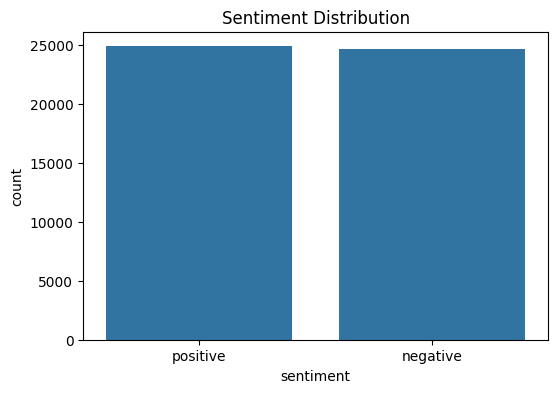

In [33]:
plt.figure(figsize=(6,4))

sns.countplot(x=df["sentiment"])

plt.title("Sentiment Distribution")

plt.show()

In [34]:
ps=PorterStemmer()

stop_words=set(stopwords.words("english"))

def clean_text(text):

    text=text.lower()

    text=re.sub("[^a-zA-Z]"," ",text)

    words=text.split()

    words=[ps.stem(word) for word in words if word not in stop_words]

    return " ".join(words)

In [35]:
df["clean_review"]=df["review"].apply(clean_text)

df[["review","clean_review"]].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one review mention watch oz episod hook right ...
1,A wonderful little production. <br /><br />The...,wonder littl product br br film techniqu unass...
2,I thought this was a wonderful way to spend ti...,thought wonder way spend time hot summer weeke...
3,Basically there's a family where a little boy ...,basic famili littl boy jake think zombi closet...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visual stun film...


In [36]:
df["sentiment"]=df["sentiment"].map({"positive":1,"negative":0})

df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,1,one review mention watch oz episod hook right ...
1,A wonderful little production. <br /><br />The...,1,wonder littl product br br film techniqu unass...
2,I thought this was a wonderful way to spend ti...,1,thought wonder way spend time hot summer weeke...
3,Basically there's a family where a little boy ...,0,basic famili littl boy jake think zombi closet...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter mattei love time money visual stun film...


In [37]:
tfidf=TfidfVectorizer(max_features=5000)

X=tfidf.fit_transform(df["clean_review"]).toarray()

y=df["sentiment"]

In [38]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
model=LogisticRegression()

model.fit(X_train,y_train)

LogisticRegression()

In [40]:
y_pred=model.predict(X_test)

In [41]:
accuracy=accuracy_score(y_test,y_pred)

print("Accuracy :",accuracy)

Accuracy : 0.8859534133306444


In [42]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4939
           1       0.87      0.90      0.89      4978

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



In [43]:
review=input("Enter Movie Review : ")

Enter Movie Review : This movie was absolutely amazing. The acting was fantastic and the storyline was excellent.


In [44]:
review=clean_text(review)

review=tfidf.transform([review]).toarray()

prediction=model.predict(review)

if prediction[0]==1:
    print("Positive Review 😊")

else:
    print("Negative Review 😞")

Positive Review 😊
